In [76]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os

In [77]:
carpeta = 'images/'
archivos = os.listdir(carpeta)

def draw_images(img,template):
    plt.figure(figsize=(12,5))
    plt.subplot(121)
    plt.imshow(template, cmap='gray')
    plt.title('Template')
    plt.axis('off')
    plt.subplot(122)
    plt.imshow(img, cmap='gray')
    plt.title('Imagen')
    plt.axis('off')
    plt.show()


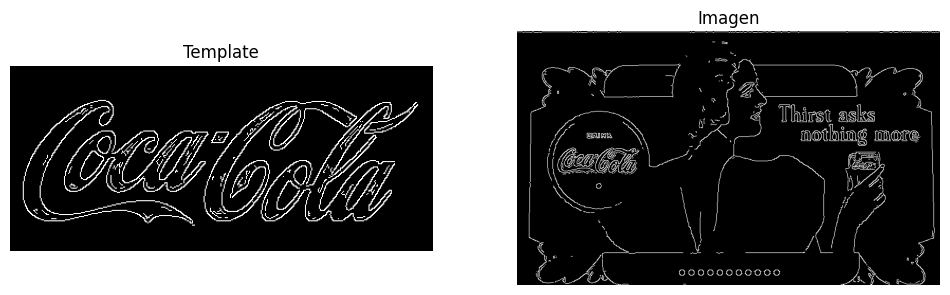

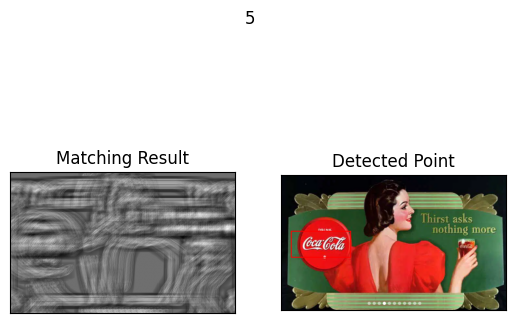

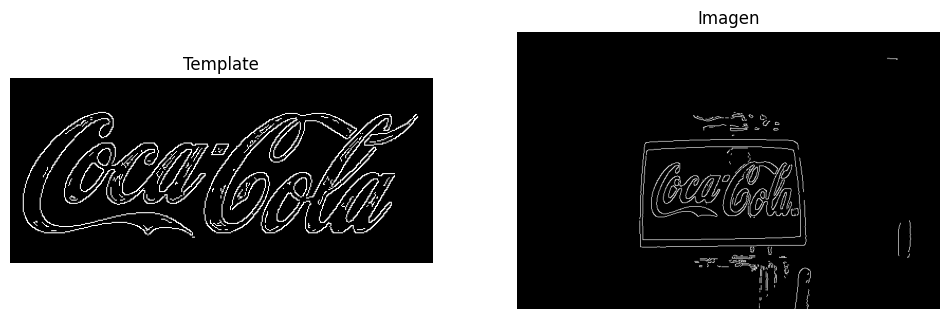

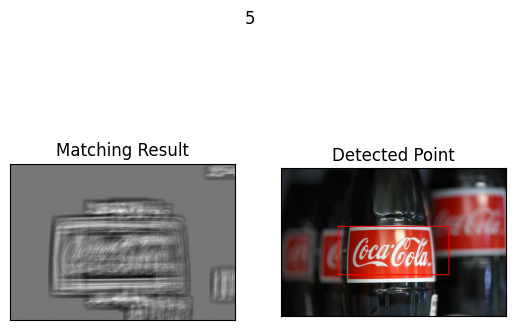

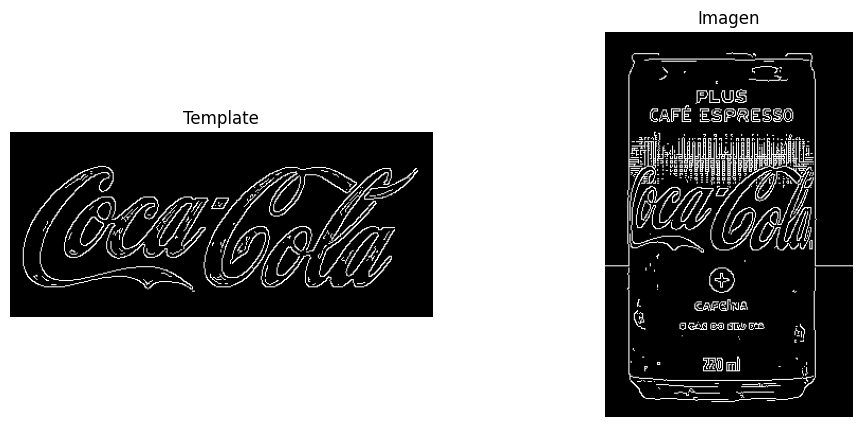

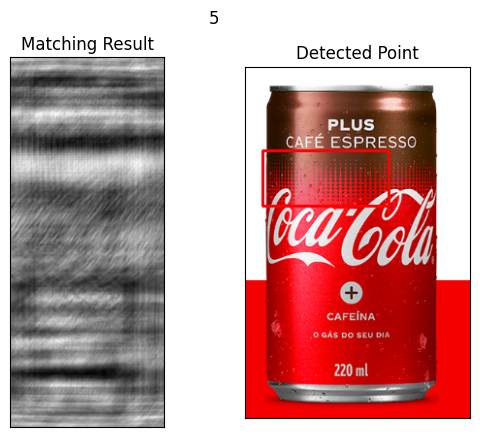

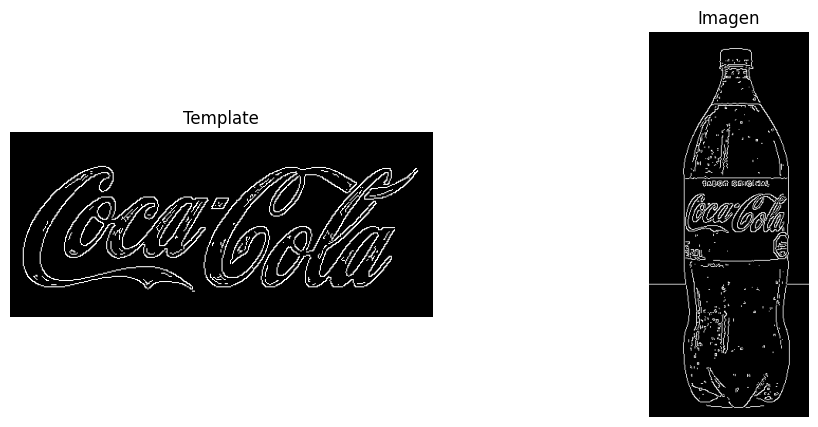

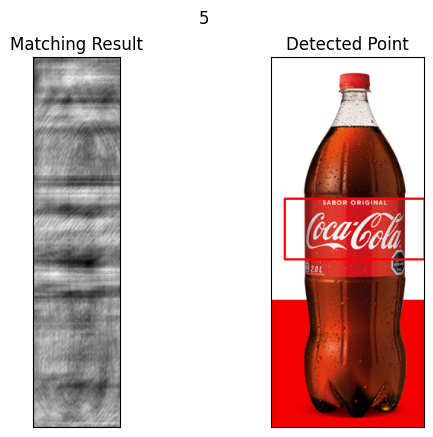

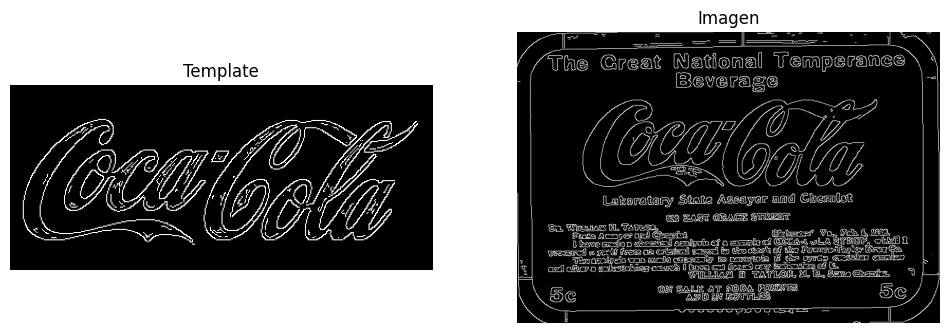

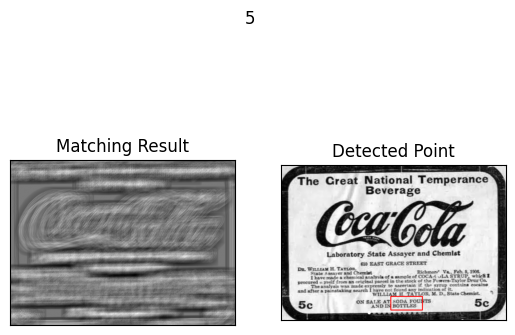

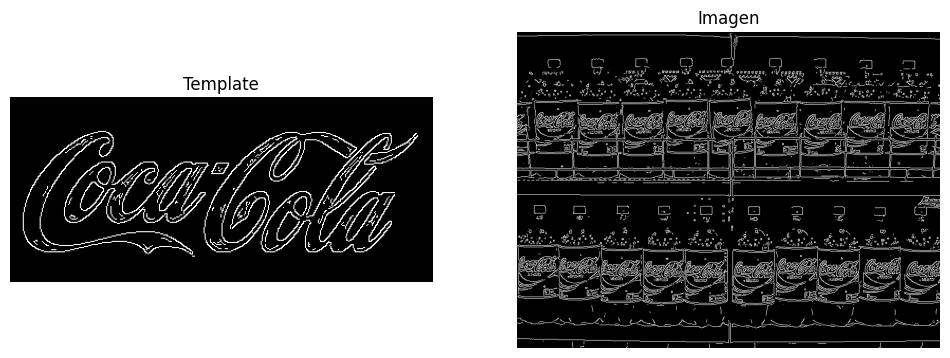

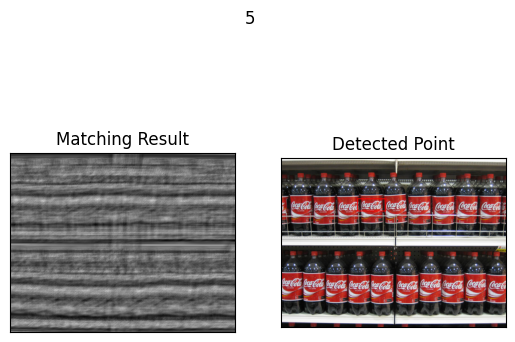

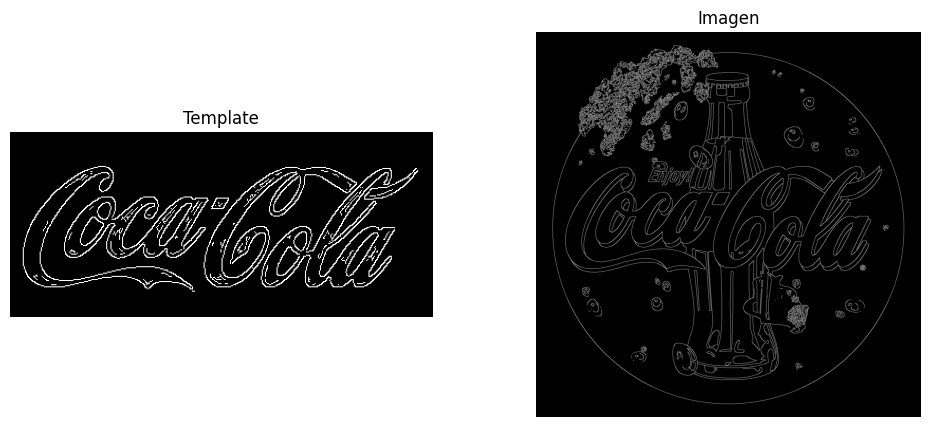

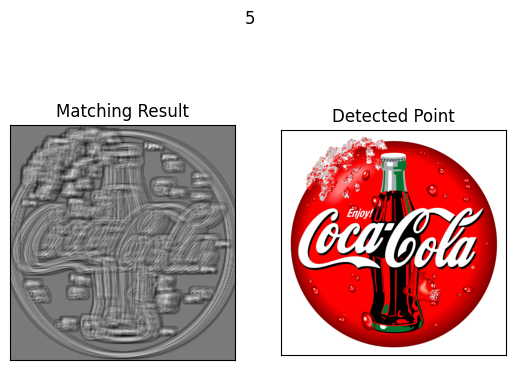

In [84]:

method = cv.TM_CCOEFF_NORMED

for archivo in archivos:
    #Cargo imagen
    img = cv.imread(carpeta + archivo)
    img_rgb= cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img_borders = cv.Canny(img, 220, 260)
    #Cargo template
    template = cv.imread('template/pattern.png', 0)
    template = cv.Canny(template, 30, 90)
    h, w = template.shape
    draw_images(img_borders,template)
    w, h = template.shape[::-1]
# Aplicamos la coincidencia de patrones
#--------------------------------------
    img_salida = img_rgb.copy()
    best_score = -1
    best_loc = None
    best_scale = None
    scales = np.linspace(0.25, 4.0 , 5)
    for s in scales:
    # Redimensionamos la imagen

        resized = cv.resize(img_borders, None, fx=s, fy=s)
        if(resized.shape[0] < template.shape[0] or resized.shape[1] < template.shape[1]):
            continue
        res = cv.matchTemplate(resized, template, method)
        min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)
    
    # Encontramos los valores máximos y mínimos
        if  max_val > best_score:
            best_score = max_val
            best_loc = max_loc
            best_scale = s

    top_left = (int(best_loc[0] / best_scale), int(best_loc[1] / best_scale))
    bottom_right = (top_left[0] + int(w/best_scale), top_left[1] + int(h / best_scale))


    cv.rectangle(img_salida,top_left, bottom_right, 255, 2)
    
    # Graficamos el procesamiento y la salida
    #----------------------------------------
    plt.figure()
    
    # Resultado de coincidencia
    plt.subplot(121),plt.imshow(res,cmap = 'gray')
    plt.title('Matching Result'), plt.xticks([]), plt.yticks([])
    
    # Imagen original con recuadros
    plt.subplot(122),plt.imshow(img_salida)
    plt.title('Detected Point'), plt.xticks([]), plt.yticks([])
    
    plt.suptitle(method)
    plt.show()

### Plantear y validar un algoritmo para múltiples detecciones en la imagencoca_multi.png con el mismo témplate del ítem 1